# Human Activity Recognition Using Hidden Markov Models

This notebook implements a full pipeline for recognizing human activities (Still, Standing, Walking, Jumping) from smartphone accelerometer and gyroscope signals using Hidden Markov Models (HMMs).


## Section 0: Install & Import Dependencies

In [1]:
# Install required libraries
!pip install hmmlearn scikit-learn pandas numpy matplotlib seaborn scipy -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from hmmlearn import hmm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("All libraries loaded successfully.")

All libraries loaded successfully.



## Section 1 — Data Loading & Preprocessing

### 1.1 Configuration

In [3]:
# Paths
TRAIN_ROOT = os.path.join('data', 'train')
TEST_ROOT  = os.path.join('data', 'test')

# Activity labels (canonical lowercase)
ACTIVITIES     = ['still', 'standing', 'walking', 'jumping']
ACTIVITY_TO_ID = {a: i for i, a in enumerate(ACTIVITIES)}
ID_TO_ACTIVITY = {i: a for a, i in ACTIVITY_TO_ID.items()}

# Signal processing 
# resample everything to 50 Hz so all feature windows are consistent.
TARGET_FS   = 50    # Hz — common resampled rate
WINDOW_SIZE = 50    # samples = 1 second at 50 Hz
STEP_SIZE   = 25    # 50% overlap gives more training windows per recording

print(f"Target sampling rate : {TARGET_FS} Hz")
print(f"Window size          : {WINDOW_SIZE} samples = {WINDOW_SIZE/TARGET_FS:.1f} second")
print(f"Step size            : {STEP_SIZE} samples = {STEP_SIZE/TARGET_FS:.2f} s (50% overlap)")
print()
print("Window size justification:")
print("  At 50 Hz, 50 samples = 1 second per window.")
print("  1 second is long enough to capture a full stride (walking)")
print("  or jump cycle, while short enough to stay within a single activity.")
print("  50% overlap maximises the number of training windows without")
print("  introducing excessive redundancy.")

Target sampling rate : 50 Hz
Window size          : 50 samples = 1.0 second
Step size            : 25 samples = 0.50 s (50% overlap)

Window size justification:
  At 50 Hz, 50 samples = 1 second per window.
  1 second is long enough to capture a full stride (walking)
  or jump cycle, while short enough to stay within a single activity.
  50% overlap maximises the number of training windows without
  introducing excessive redundancy.


### 1.2 Load & Merge a Single Recording

In [4]:
def load_recording(sample_dir):
    """
    Loads Accelerometer.csv and Gyroscope.csv from `sample_dir`,
    merges on a common time axis using linear interpolation,
    resamples to TARGET_FS Hz.

    Returns:
        (merged_df, native_fs_accel, native_fs_gyro)
        or None if files are missing / unreadable.

    merged_df columns: t, accel_x, accel_y, accel_z, gyro_x, gyro_y, gyro_z
    """
    acc_path = os.path.join(sample_dir, 'Accelerometer.csv')
    gyr_path = os.path.join(sample_dir, 'Gyroscope.csv')

    if not (os.path.exists(acc_path) and os.path.exists(gyr_path)):
        return None

    try:
        acc = pd.read_csv(acc_path)
        gyr = pd.read_csv(gyr_path)
    except Exception:
        return None

    # Normalise column names
    acc.columns = acc.columns.str.lower().str.strip()
    gyr.columns = gyr.columns.str.lower().str.strip()

    if 'seconds_elapsed' not in acc.columns or 'seconds_elapsed' not in gyr.columns:
        return None

    acc = acc.rename(columns={'x': 'accel_x', 'y': 'accel_y', 'z': 'accel_z'})
    gyr = gyr.rename(columns={'x': 'gyro_x',  'y': 'gyro_y',  'z': 'gyro_z'})

    acc = acc[['seconds_elapsed', 'accel_x', 'accel_y', 'accel_z']].dropna()
    gyr = gyr[['seconds_elapsed', 'gyro_x',  'gyro_y',  'gyro_z']].dropna()

    # Detect native sampling rates from median time difference
    fs_acc = 1.0 / np.median(np.diff(acc['seconds_elapsed'].values))
    fs_gyr = 1.0 / np.median(np.diff(gyr['seconds_elapsed'].values))

    # Common time axis (overlap region only)
    t_start = max(acc['seconds_elapsed'].iloc[0],  gyr['seconds_elapsed'].iloc[0])
    t_end   = min(acc['seconds_elapsed'].iloc[-1], gyr['seconds_elapsed'].iloc[-1])
    if t_end <= t_start:
        return None

    t_new = np.arange(t_start, t_end, 1.0 / TARGET_FS)

    def resample_sensor(df, time_col, value_cols, t_new):
        t = df[time_col].values
        out = {'t': t_new}
        for col in value_cols:
            f = interp1d(t, df[col].values, kind='linear',
                         bounds_error=False, fill_value='extrapolate')
            out[col] = f(t_new)
        return pd.DataFrame(out)

    acc_r = resample_sensor(acc, 'seconds_elapsed',
                            ['accel_x', 'accel_y', 'accel_z'], t_new)
    gyr_r = resample_sensor(gyr, 'seconds_elapsed',
                            ['gyro_x', 'gyro_y', 'gyro_z'], t_new)

    merged = acc_r.copy()
    merged['gyro_x'] = gyr_r['gyro_x'].values
    merged['gyro_y'] = gyr_r['gyro_y'].values
    merged['gyro_z'] = gyr_r['gyro_z'].values

    return merged, round(fs_acc), round(fs_gyr)


print("load_recording() defined.")

load_recording() defined.


### 1.3 Scan Dataset & Report Sampling Rates

In [5]:
def scan_dataset(root):
    """
    Walk directory tree under `root`.
    Returns list of (sample_dir, activity_label, participant) tuples.
    Handles both lowercase and capitalised folder names.
    """
    samples = []
    for participant in sorted(os.listdir(root)):
        p_path = os.path.join(root, participant)
        if not os.path.isdir(p_path):
            continue
        for activity in sorted(os.listdir(p_path)):
            a_path = os.path.join(p_path, activity)
            if not os.path.isdir(a_path):
                continue
            label = activity.lower().strip()   # normalise to lowercase
            if label not in ACTIVITIES:
                continue
            for session in sorted(os.listdir(a_path)):
                s_path = os.path.join(a_path, session)
                if not os.path.isdir(s_path):
                    continue
                if os.path.exists(os.path.join(s_path, 'Accelerometer.csv')):
                    samples.append((s_path, label, participant))
    return samples


train_samples = scan_dataset(TRAIN_ROOT)
test_samples  = scan_dataset(TEST_ROOT)

print(f"Train samples found : {len(train_samples)}")
print(f"Test  samples found : {len(test_samples)}")
print()
print("Train distribution  :", dict(Counter(l for _, l, _ in train_samples)))
print("Test  distribution  :", dict(Counter(l for _, l, _ in test_samples)))

Train samples found : 49
Test  samples found : 24

Train distribution  : {'jumping': 12, 'standing': 12, 'still': 13, 'walking': 12}
Test  distribution  : {'jumping': 6, 'standing': 6, 'still': 6, 'walking': 6}


In [6]:
# Detect and report native sampling rates
rate_info = {}
for s_dir, label, participant in train_samples:
    result = load_recording(s_dir)
    if result is not None:
        _, fs_acc, fs_gyr = result
        rate_info.setdefault(participant, {'acc': [], 'gyr': []})
        rate_info[participant]['acc'].append(fs_acc)
        rate_info[participant]['gyr'].append(fs_gyr)

print("Native sampling rates detected from data:")
print("-" * 55)
for participant, rates in rate_info.items():
    acc_med = int(np.median(rates['acc']))
    gyr_med = int(np.median(rates['gyr']))
    print(f"  {participant:<12}  accel: ~{acc_med} Hz   gyro: ~{gyr_med} Hz")
print("-" * 55)
print(f"  → All resampled to {TARGET_FS} Hz for consistency.")

Native sampling rates detected from data:
-------------------------------------------------------
  alliance      accel: ~53 Hz   gyro: ~53 Hz
  emmanuel      accel: ~54 Hz   gyro: ~54 Hz
-------------------------------------------------------
  → All resampled to 50 Hz for consistency.


### 1.4 Visualise Raw Sensor Signals per Activity

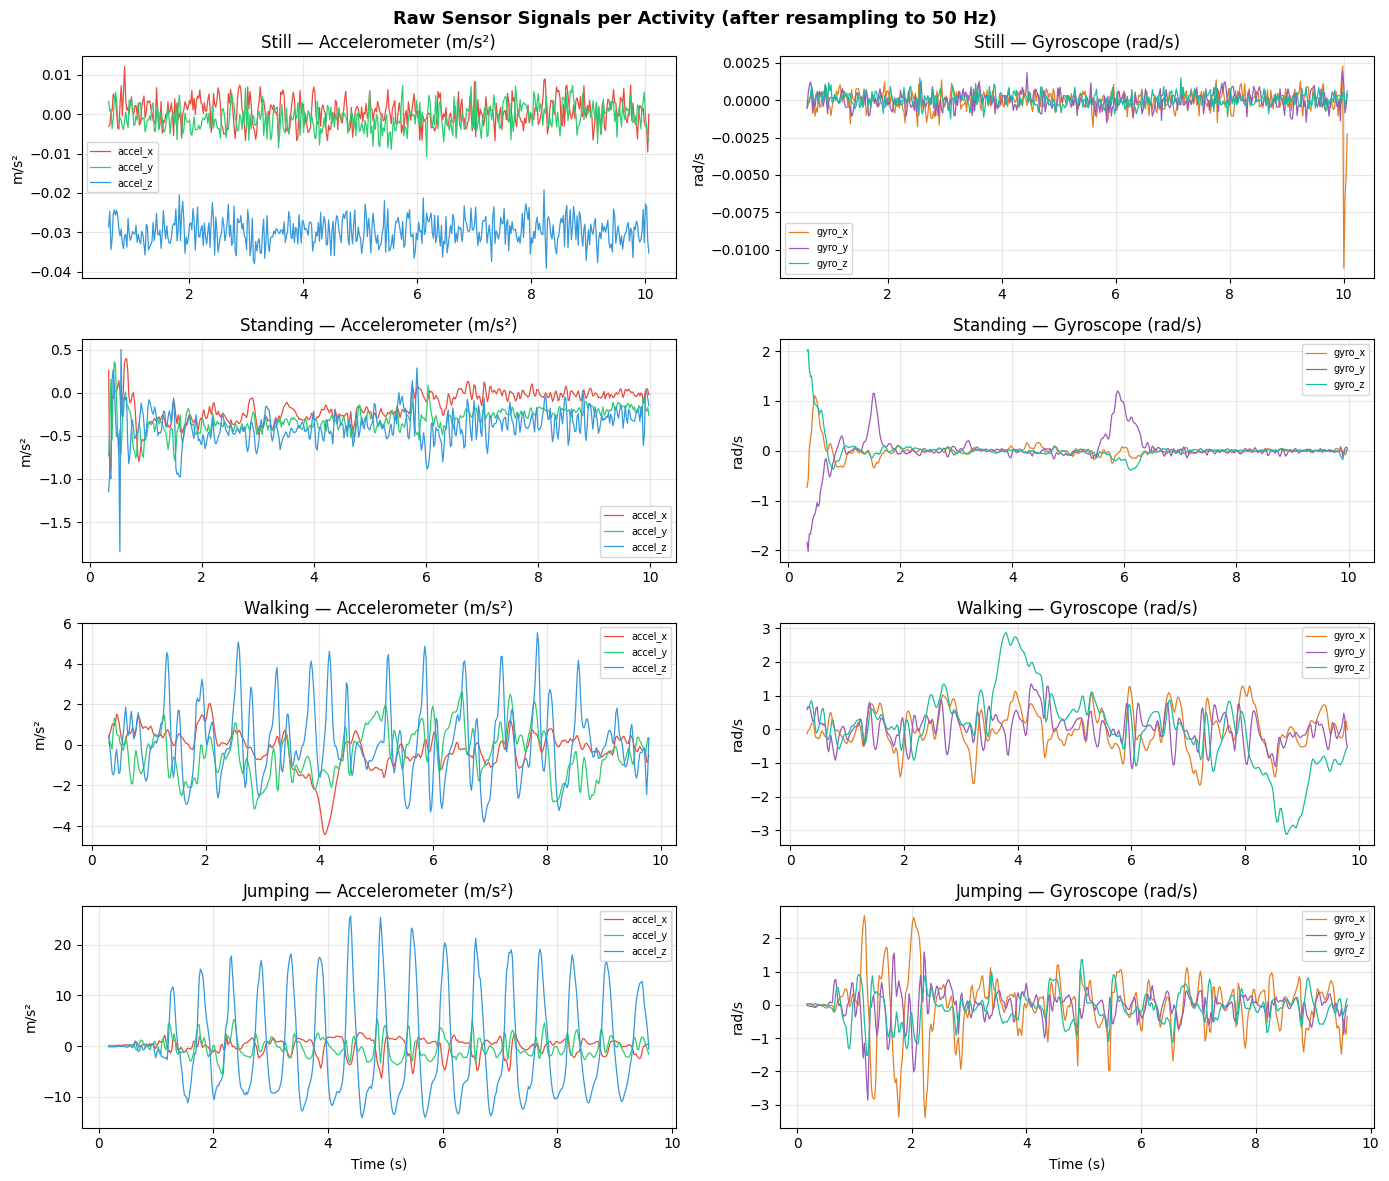

Figure saved as raw_signals.png


In [7]:
# Collect one sample path per activity
activity_samples = {a: [] for a in ACTIVITIES}
for s_dir, label, _ in train_samples:
    activity_samples[label].append(s_dir)

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
fig.suptitle('Raw Sensor Signals per Activity (after resampling to 50 Hz)',
             fontsize=13, fontweight='bold')

colors = {
    'accel_x': '#e74c3c', 'accel_y': '#2ecc71', 'accel_z': '#3498db',
    'gyro_x' : '#e67e22', 'gyro_y' : '#9b59b6', 'gyro_z' : '#1abc9c'
}

for row, activity in enumerate(ACTIVITIES):
    if not activity_samples[activity]:
        continue
    result = load_recording(activity_samples[activity][0])
    if result is None:
        continue
    df, _, _ = result

    ax_a = axes[row, 0]
    ax_g = axes[row, 1]

    for col in ['accel_x', 'accel_y', 'accel_z']:
        ax_a.plot(df['t'], df[col], label=col,
                  color=colors[col], linewidth=0.9)
    ax_a.set_title(f'{activity.capitalize()} — Accelerometer (m/s²)')
    ax_a.set_ylabel('m/s²')
    ax_a.legend(fontsize=7)
    ax_a.grid(True, alpha=0.3)

    for col in ['gyro_x', 'gyro_y', 'gyro_z']:
        ax_g.plot(df['t'], df[col], label=col,
                  color=colors[col], linewidth=0.9)
    ax_g.set_title(f'{activity.capitalize()} — Gyroscope (rad/s)')
    ax_g.set_ylabel('rad/s')
    ax_g.legend(fontsize=7)
    ax_g.grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig('raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as raw_signals.png")

---
## Section 2 — Feature Extraction

### 2.1 Feature Functions

We extract **58 features** per window

In [13]:
def extract_features(window_df, fs=TARGET_FS):
    """
    Extract time domain and frequency domain features from one window.
    Returns a 1-D numpy array of length 58.
    """
    axes_list = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']
    features  = []
    signals   = {a: window_df[a].values for a in axes_list}

    # Time domain: mean, variance, std, RMS 
    for ax in axes_list:
        s = signals[ax]
        features.append(np.mean(s))                   # mean
        features.append(np.var(s))                    # variance
        features.append(np.std(s))                    # standard deviation
        features.append(np.sqrt(np.mean(s ** 2)))     # RMS

    # Signal Magnitude Area (SMA) 
    sma_accel = (np.sum(np.abs(signals['accel_x']) +
                        np.abs(signals['accel_y']) +
                        np.abs(signals['accel_z'])) / len(signals['accel_x']))
    sma_gyro  = (np.sum(np.abs(signals['gyro_x'])  +
                        np.abs(signals['gyro_y'])  +
                        np.abs(signals['gyro_z']))  / len(signals['gyro_x']))
    features.append(sma_accel)
    features.append(sma_gyro)

    # Cross-axis correlations
    pairs = [
        ('accel_x','accel_y'), ('accel_x','accel_z'), ('accel_y','accel_z'),
        ('gyro_x', 'gyro_y'),  ('gyro_x', 'gyro_z'),  ('gyro_y', 'gyro_z')
    ]
    for a1, a2 in pairs:
        corr = np.corrcoef(signals[a1], signals[a2])[0, 1]
        features.append(0.0 if np.isnan(corr) else corr)

    #Frequency-domain: dominant frequency & spectral energy (FFT)
    n     = len(signals['accel_x'])
    freqs = fftfreq(n, d=1.0 / fs)[:n // 2]

    for ax in axes_list:
        s        = signals[ax]
        fft_vals = np.abs(fft(s))[:n // 2]

        dom_freq    = freqs[np.argmax(fft_vals)] if len(fft_vals) > 0 else 0.0
        spec_energy = np.sum(fft_vals ** 2) / n

        features.append(dom_freq)     # dominant frequency (Hz)
        features.append(spec_energy)  # spectral energy

    return np.array(features, dtype=np.float32)


# Feature names (for labelling plots)
feature_names = []
for ax in ['acc_x','acc_y','acc_z','gyr_x','gyr_y','gyr_z']:
    for stat in ['mean','var','std','rms']:
        feature_names.append(f'{ax}_{stat}')
feature_names += ['sma_acc', 'sma_gyr']
feature_names += ['corr_ax_ay','corr_ax_az','corr_ay_az',
                  'corr_gx_gy','corr_gx_gz','corr_gy_gz']
for ax in ['acc_x','acc_y','acc_z','gyr_x','gyr_y','gyr_z']:
    feature_names += [f'{ax}_domfreq', f'{ax}_energy']

# Sanity check
result = load_recording(train_samples[0][0])
if result:
    df_sample, _, _ = result
    test_feat = extract_features(df_sample.iloc[:WINDOW_SIZE])
    print(f"Feature vector length : {len(test_feat)}  (expected 44)")
    print(f"Feature names count   : {len(feature_names)}")

Feature vector length : 44  (expected 44)
Feature names count   : 44


### 2.2 Sliding-Window Extraction Pipeline

In [14]:
def extract_all_features(sample_list, window_size=WINDOW_SIZE, step=STEP_SIZE):
    """
    Process all recordings in sample_list using a sliding window.
    Returns:
        X       - (N, 58) feature matrix
        y       - (N,)    integer activity labels
        lengths - list of window counts per recording (required by hmmlearn)
    """
    all_features, all_labels, lengths = [], [], []
    skipped = 0

    for s_dir, label, participant in sample_list:
        result = load_recording(s_dir)
        if result is None:
            skipped += 1
            continue
        df, _, _ = result

        if len(df) < window_size:
            skipped += 1
            continue

        seq_features = []
        for start in range(0, len(df) - window_size + 1, step):
            window = df.iloc[start:start + window_size]
            feat   = extract_features(window)
            seq_features.append(feat)
            all_labels.append(ACTIVITY_TO_ID[label])

        all_features.extend(seq_features)
        lengths.append(len(seq_features))

    if skipped:
        print(f"  Skipped {skipped} recordings (missing files or too short).")

    return np.array(all_features), np.array(all_labels), lengths


print("Extracting training features...")
X_train, y_train, train_lengths = extract_all_features(train_samples)
print(f"  X_train : {X_train.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  sequences: {len(train_lengths)}")

print("\nExtracting test features...")
X_test, y_test, test_lengths = extract_all_features(test_samples)
print(f"  X_test  : {X_test.shape}")
print(f"  y_test  : {y_test.shape}")

Extracting training features...
  X_train : (948, 44)
  y_train : (948,)
  sequences: 49

Extracting test features...
  X_test  : (464, 44)
  y_test  : (464,)


### 2.3 Z-Score Normalisation

In [18]:
# Z-score normalisation chosen because:
#  Features have very different scales (m/s² vs rad/s vs Hz)
#  Z-score centres each feature at 0 with std=1
#  Scaler is fit ONLY on training data to avoid data leakage

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print("Z-score normalisation applied.")
print(f"  Train — mean: {X_train_scaled.mean():.4f}  std: {X_train_scaled.std():.4f}")
print(f"  Test  — mean: {X_test_scaled.mean():.4f}  std: {X_test_scaled.std():.4f}")

Z-score normalisation applied.
  Train — mean: 0.0000  std: 1.0000
  Test  — mean: 0.0209  std: 1.0224


### 2.4 Feature Distribution Visualisation

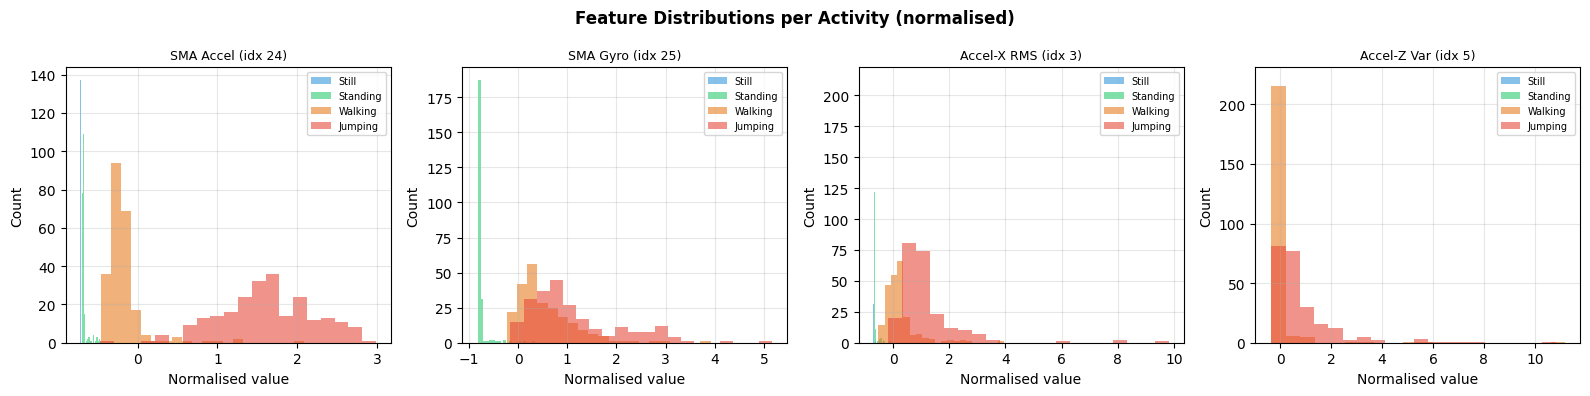

Saved feature_distributions.png


In [19]:
# Plot distribution of 4 key features across activities
key_features = {
    'SMA Accel (idx 24)'    : 24,
    'SMA Gyro (idx 25)'     : 25,
    'Accel-X RMS (idx 3)'   : 3,
    'Accel-Z Var (idx 5)'   : 5
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Feature Distributions per Activity (normalised)',
             fontsize=12, fontweight='bold')

activity_colors = {
    'still': '#3498db', 'standing': '#2ecc71',
    'walking': '#e67e22', 'jumping': '#e74c3c'
}

for ax, (fname, fidx) in zip(axes, key_features.items()):
    for act_id, act_name in ID_TO_ACTIVITY.items():
        vals = X_train_scaled[y_train == act_id, fidx]
        ax.hist(vals, bins=20, alpha=0.6,
                label=act_name.capitalize(),
                color=activity_colors[act_name])
    ax.set_title(fname, fontsize=9)
    ax.set_xlabel('Normalised value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved feature_distributions.png")